In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plumed
import seaborn as sns
from scipy.stats import gaussian_kde
import numpy as np

In [2]:
def search_contacts(df, chain, resi):
    search = rf"^{chain}:.*:{resi}$"
    mask = df.astype(str).apply(
        lambda col: col.str.contains(search, regex=True, na=False)
    ).any(axis=1)
    return df[mask]
def plot_contacts(df):
    plt.figure(figsize=(10, 6))
    for col in df.columns:
        plt.plot(df.index, df[col], label=f'Column {col}')
    plt.xlabel('Frame')
    plt.ylabel('Contact Value')
    plt.title('Contact Values Over Time')
    plt.legend()
    plt.show()

##### 查找单个氨基酸

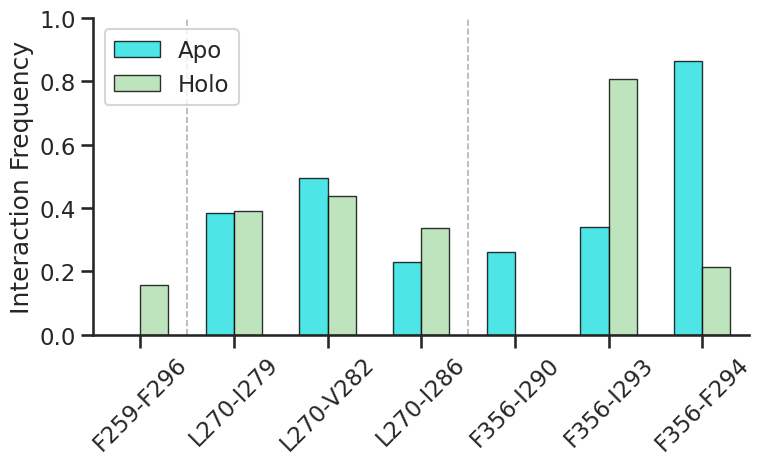

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. 配置参数 ---
base_path = '/workdir/AgOR10_28/AgOR10/'
itype = 'hp'
state_order = ["Apo", "Holo"]
# colors = {"Apo": '#2C7BB6', "Holo": '#D7191C'}
colors = {
    "Apo": (0.0, 1.0, 1.0),        # #00FFFF
    "Holo": (0.65, 0.9, 0.65)  # #A6E6A6
}
# 残基映射表
res_map = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
}

# 严格按照你要求的顺序定义 targets
targets = [
    {"search": "A:PHE:259", "exclude": "66|67|289|293|359", "label": "F259"}, # 放在第一
    {"search": "A:LEU:270", "exclude": "367", "label": "L270"},         # 放在第二
    {"search": "A:PHE:356", "exclude": "353|360", "label": "F356"}          # 放在最后
]

paths = {
    "Apo": f"{base_path}AgOR10_apo/cuts1/protein_{itype}.tsv",
    "Holo": f"{base_path}AgOR10_bound/protein_{itype}.tsv"
}

# --- 2. 数据处理 ---
all_processed_data = []

def get_short_name(res_str):
    """A:PHE:356 -> F356"""
    try:
        parts = res_str.replace("A:", "").split(":")
        return f"{res_map.get(parts[0], parts[0])}{parts[1]}"
    except:
        return res_str

for target in targets:
    for state, path in paths.items():
        try:
            df = pd.read_csv(path, sep='\t', skiprows=2, header=None)
            search = target["search"]
            df_sub = df[(df[0] == search) | (df[1] == search)].copy()
            df_sub["partner"] = df_sub.apply(lambda row: row[1] if row[0] == search else row[0], axis=1)
            df_sub = df_sub[~df_sub["partner"].str.startswith("D:")]
            df_sub = df_sub[~df_sub["partner"].str.contains(target["exclude"])]
            
            df_sub["partner_short"] = df_sub["partner"].apply(get_short_name)
            df_sub["display_name"] = target["label"] + "-" + df_sub["partner_short"]
            df_sub['res_num'] = df_sub['partner'].str.extract('(\d+)').astype(int)
            df_sub["State"] = state
            df_sub["Target_Group"] = target["label"]
            
            df_sub = df_sub[df_sub[2] > 0.1]
            all_processed_data.append(df_sub)
        except:
            continue

df_final = pd.concat(all_processed_data)

# --- 3. 强制排序核心逻辑 ---
# 1. 按照 targets 定义的顺序创建 Target 分组顺序
target_order = [t["label"] for t in targets]
df_final["Target_Group"] = pd.Categorical(df_final["Target_Group"], categories=target_order, ordered=True)

# 2. 先按 Target 顺序排，同组内按残基编号排
df_final = df_final.sort_values(by=['Target_Group', 'res_num'])

# 3. 锁定 display_name 的唯一顺序，防止绘图时乱序
ordered_display_names = df_final["display_name"].unique()
df_final["display_name"] = pd.Categorical(df_final["display_name"], categories=ordered_display_names, ordered=True)

# --- 4. 绘图 ---
num_x_ticks = len(ordered_display_names)
dynamic_width = max(8, num_x_ticks * 0.6 + 2) # 每个刻度 0.6 英寸
fig, ax = plt.subplots(figsize=(dynamic_width, 5))
sns.set_theme(style="ticks", context="talk")

# width=0.4 确保柱子细且等宽
sns.barplot(
    data=df_final, x="display_name", y=2, hue="State", 
    hue_order=state_order, palette=colors, 
    width=0.6, edgecolor="black", linewidth=1, ax=ax,alpha=0.8
)

# --- 5. 分组虚线 ---
current_pos = -0.5
for t_label in target_order[:-1]:
    # 统计当前 Target 组下有多少个唯一的 partner（即占用了多少个 X 轴位置）
    group_count = df_final[df_final["Target_Group"] == t_label]["display_name"].nunique()
    if group_count > 0:
        current_pos += group_count
        ax.axvline(x=current_pos, color='black', linestyle='--', linewidth=1.2, alpha=0.3)

# --- 6. 修饰 ---
ax.set_ylim(0, 1)
ax.set_ylabel("Interaction Frequency")
ax.set_xlabel("")
ax.legend()
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.savefig('Merged_Final_Ordered.pdf', dpi=300)
plt.show()

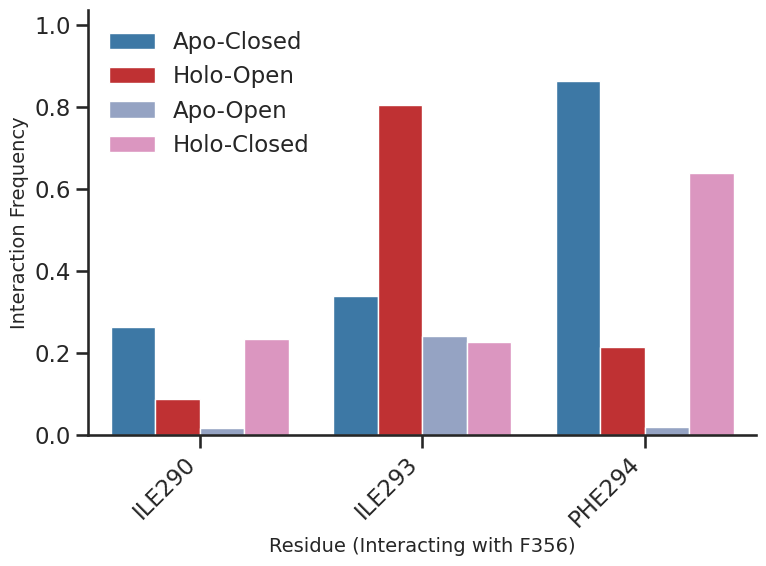

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

search = "A:PHE:356"
itype = 'hp'
base_path = '/workdir/AgOR10_28/AgOR10/'
paths = {
    "Apo-Closed": f"{base_path}AgOR10_apo/cuts1/protein_{itype}.tsv",
    "Holo-Open": f"{base_path}AgOR10_bound/protein_{itype}.tsv",
    "Apo-Open": f"{base_path}AgOR10_apo_open/protein_{itype}.tsv",
    "Holo-Closed": f"{base_path}AgOR10_bound_close/protein_{itype}.tsv"
}

all_data = []

# --- 1. 数据读取与统一处理逻辑 ---
for state, path in paths.items():
    df = pd.read_csv(path, sep='\t', skiprows=2, header=None)
    
    # 筛选包含 search 的行
    df_sub = df[(df[0] == search) | (df[1] == search)].copy()
    
    # 提取“另一方”残基
    df_sub["partner"] = df_sub.apply(
        lambda row: row[1] if row[0] == search else row[0], axis=1
    )
    
    # 过滤：排除 D: 链，排除特定残基
    df_sub = df_sub[~df_sub["partner"].str.startswith("D:")]
    df_sub = df_sub[~df_sub["partner"].str.contains("59|60|269|353|356|298")] # 使用正则合并排除
    
    # 格式化名称
    df_sub["partner_short"] = df_sub["partner"].str.replace("A:", "", regex=False)
    df_sub["partner_short"] = df_sub["partner_short"].str.replace(":", "")
    # 提取残基编号以便排序
    df_sub['res_num'] = df_sub['partner_short'].str.extract('(\d+)').astype(int)
    
    # 记录状态
    df_sub["State"] = state
    
    # 筛选频率
    df_sub = df_sub[df_sub[2] > 0]
    all_data.append(df_sub)

# 合并数据
df_combined = pd.concat(all_data).sort_values(by='res_num')

# --- 2. 视觉美化设置 ---
sns.set_theme(style="ticks", context="talk")
plt.figure(figsize=(8, 6))

# 使用 hue 来对比 Apo 和 Bound
# palette 可以选择 'Paired', 'Set1' 或者自定义颜色
colors = {"Apo-Closed": '#2C7BB6',"Apo-Open": '#8DA0CB', "Holo-Open": '#D7191C',  "Holo-Closed": '#E78AC3'}

ax = sns.barplot(
    x="partner_short", 
    y=2, 
    hue="State",
    data=df_combined, 
    palette=colors,
    edgecolor="white",
    linewidth=1
)

# --- 3. 添加分组标签 (如 S6) ---
# 获取当前的 x 轴刻度位置
unique_partners = df_combined['partner_short'].unique()
y_max = df_combined[2].max()

# 示例：如果前两个残基属于 S6
# 注意：合并后 x 轴索引取决于 unique_partners 的顺序
# groups = [{"label": "S6", "start": 0, "end": 1}]

# for g in groups:
#     mid_point = (g["start"] + g["end"]) / 2
#     plt.text(mid_point, y_max * 1.1, g["label"], ha='center', fontweight='bold')
#     if g["start"] != g["end"]:
#         plt.hlines(y_max * 1.08, g["start"]-0.2, g["end"]+0.2, colors='0.5', lw=1)

# --- 4. 细节打磨 ---
sns.despine()
plt.xlabel("Residue (Interacting with F356)", fontsize=14)
plt.ylabel("Interaction Frequency", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.legend( frameon=False) # 移除图例边框

# 动态调整 y 轴
plt.ylim(0, y_max * 1.2)

plt.tight_layout()
plt.savefig('F356_Apo_vs_Bound.pdf', dpi=300)
plt.show()

In [ ]:
itype = 'hp'
df = pd.read_csv(f'/workdir/AgOR10_28/AgOR10/AgOR10_bound/protein_{itype}.tsv', sep='\t', skiprows=2, header=None)

chain1 = 'A'
resi1 =255
df_matched = search_contacts(df, chain1, resi1)
search = "A:LEU:269"
df_sub = df[(df[0] == search) | (df[1] == search)].copy()

# 提取“另一方”残基
df_sub["partner"] = df_sub.apply(
    lambda row: row[1] if row[0] == search else row[0],
    axis=1
)
df_sub = df_sub.sort_values(by=2, ascending=False)
df_sub["partner_short"] = df_sub["partner"].str.replace("X:", "")
df_sub = df_sub[df_sub[2] > 0.1]

plt.figure(figsize=(10, 5))
plt.bar(df_sub["partner"], df_sub[2])
plt.xlabel("Interacting Residue")
plt.ylabel("Interaction Frequency")
plt.title(f"Interactions with {search}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
# print(df_matched)

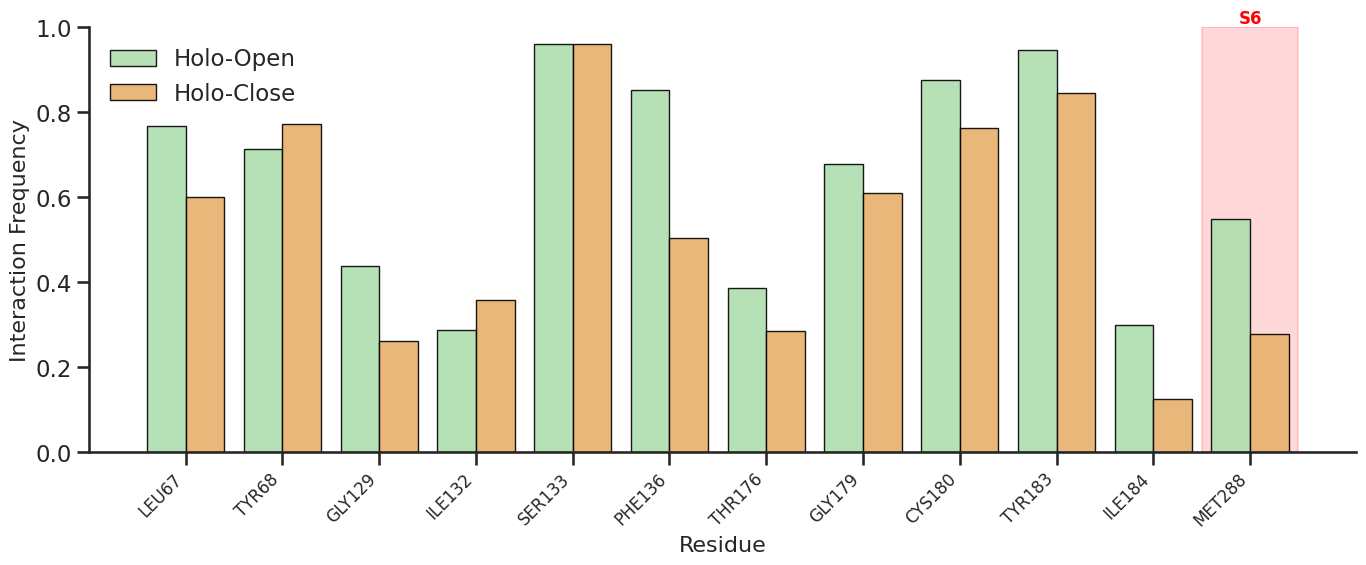

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches # 用于画框

# --- 1. 定义数据处理函数 (保持不变) ---
def get_processed_df(file_path, search_term, label):
    df = pd.read_csv(file_path, sep='\t', skiprows=2, header=None)
    df_sub = df[(df[0] == search_term) | (df[1] == search_term)].copy()
    df_sub["partner"] = df_sub.apply(
        lambda row: row[1] if row[0] == search_term else row[0], axis=1
    )
    # 清洗残基名称 (例如 A:LEU:269 -> LEU269)
    df_sub["partner_short"] = df_sub["partner"].str.replace(r'^[A-Z]:', '', regex=True).str.replace(":", "")
    df_sub = df_sub[df_sub[2] > 0.1]
    df_sub['res_num'] = df_sub['partner_short'].str.extract('(\d+)').astype(int)
    res_df = df_sub[['partner_short', 'res_num', 2]].copy()
    res_df.columns = ['Residue', 'res_num', 'Frequency']
    res_df['Ligand'] = label
    return res_df

# --- 2. 加载并合并数据 (保持不变) ---
df1 = get_processed_df('/workdir/AgOR10_28/AgOR10/AgOR10_bound/MD_vdw.tsv', 'X:JZ0:1', 'Holo-Open')
df2 = get_processed_df('/workdir/AgOR10_28/AgOR10/AgOR10_bound_close/MD_vdw.tsv', 'E:JZ0:475', 'Holo-Close')
df_all = pd.concat([df1, df2]).sort_values(by='res_num')

# --- 3. 绘图设置 ---
sns.set_theme(style="ticks", context="talk")
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df_all,
    x="Residue",
    y="Frequency",
    hue="Ligand",
    # palette={"Holo-Open": "#47A7FB", "Holo-Close": "#fcb257"},
    palette={"Holo-Open": "#A6E6A6", "Holo-Close": "#fcb257ff"},
    edgecolor="black",
    linewidth=1,
    alpha=0.9 # 稍微透明一点，让高亮背景显示出来
)

# 获取横坐标信息
unique_residues = df_all['Residue'].unique().tolist()
y_max = df_all['Frequency'].max()

# --- 4. 高亮 288 号残基 ---
highlight_res_num = 288
# 在当前的 X 轴残基列表中找到 288 的位置索引
try:
    target_idx = [i for i, res in enumerate(unique_residues) 
                   if int(''.join(filter(str.isdigit, res))) == highlight_res_num][0]
    
    # 方案 A: 添加半透明红色背景色块 (推荐，视觉效果更硬朗)
    plt.axvspan(target_idx - 0.5, target_idx + 0.5, color='red', alpha=0.15, zorder=0)
    
    # 方案 B: 在柱子周围画一个红框 (如果需要可以取消注释)
    # rect = patches.Rectangle((target_idx - 0.45, 0), 0.9, y_max * 1.1, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
    # ax.add_patch(rect)

    # 在高亮区域上方添加标签
    plt.text(target_idx, y_max * 1.05, f"S6", ha='center', color='red', fontweight='bold', fontsize=12)

except IndexError:
    print(f"Residue {highlight_res_num} not found in the filtered data.")


# --- 5. 添加 S 分组标注 (保持不变) ---
groups = [
    {"label": "S2", "start_res": 215, "end_res": 218},
    {"label": "S3", "start_res": 230, "end_res": 240},
    {"label": "S4", "start_res": 250, "end_res": 265},
    {"label": "S6", "start_res": 470, "end_res": 480}
]

# 在 y_max 留出的空间更高处标注 S 组
for g in groups:
    indices = [i for i, res in enumerate(unique_residues) 
               if g["start_res"] <= int(''.join(filter(str.isdigit, res))) <= g["end_res"]]
    if indices:
        start_idx, end_idx = min(indices), max(indices)
        mid_point = (start_idx + end_idx) / 2
        plt.text(mid_point, y_max * 1.18, g["label"], ha='center', va='bottom', fontsize=14, fontweight='bold')
        if start_idx != end_idx:
            plt.hlines(y_max * 1.16, start_idx-0.3, end_idx+0.3, colors='0.5', lw=1.5)

# --- 6. 细节打磨 ---
sns.despine()
plt.xlabel("Residue", fontsize=16)
plt.ylabel("Interaction Frequency", fontsize=16)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.legend( frameon=False)

# 留出顶部标注空间（需要更大，因为有两层标注）
plt.ylim(0, 1.0)

plt.tight_layout()
plt.savefig('ligand_comparison_highlighted.pdf', dpi=300)
plt.show()

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


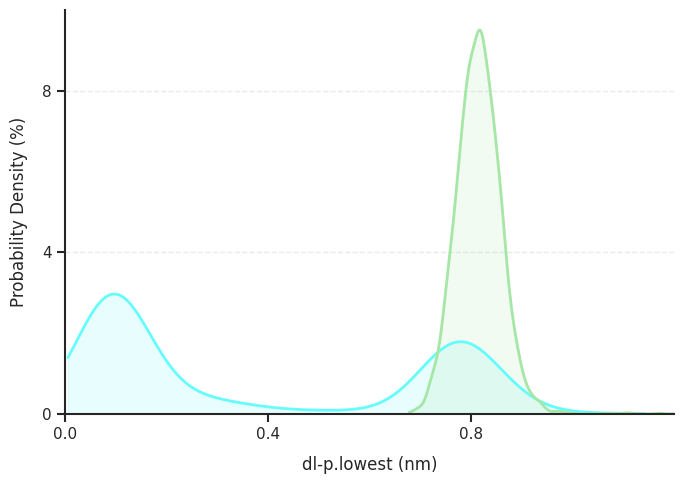

In [58]:
# 1. 设置全局样式，让图表更有“论文感”
sns.set_theme(style="ticks") # 清爽的刻度样式
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5
})

def get_kde_data(file_path, column_name):
    data = plumed.read_as_pandas(file_path)
    values = data[column_name].values
    kde = gaussian_kde(values)
    x_range = np.linspace(np.min(values), np.max(values), 300) # 增加点数让曲线更平滑
    return x_range, kde(x_range)

# 2. 准备数据
datasets = [
    {'path': 'AgOR10_apo/cuts1/COLVAR_lipid', 'label': 'Apo-Closed State', 'color':  "#67FCFC"}, # 冷蓝色
    {'path': 'AgOR10_bound/COLVAR_lipid', 'label': 'Holo-Open State', 'color': '#A6E6A6'} # 暖红色
]

fig, ax = plt.subplots(figsize=(7, 5))

# 3. 循环绘图
for ds in datasets:
    x, y = get_kde_data(ds['path'], 'dl-p.lowest')
    
    # 画主线
    ax.plot(x, y, color=ds['color'], label=ds['label'], lw=2, zorder=2)
    # 填充颜色，使用较淡的 alpha 值
    ax.fill_between(x, y, color=ds['color'], alpha=0.15, zorder=1)

# 4. 精修图表细节
ax.set_xlabel('dl-p.lowest (nm)', labelpad=10)
ax.set_ylabel('Probability Density (%)', labelpad=10)
# ax.set_title('Lipid Distribution Comparison', fontsize=14, pad=15)

# 去掉上方和右方的边框
sns.despine()

# 添加网格（可选，淡淡的灰色网格有助于读数）
ax.grid(axis='y', linestyle='--', alpha=0.4)

# 优化图例
# ax.legend(frameon=False, loc='upper right', fontsize=11)
ax.set_xlim(0,1.2)
ax.set_xticks(np.arange(0,1.2,0.4))
ax.set_ylim(0,10)
ax.set_yticks(np.arange(0,10,4))
# 自动调整布局，防止边缘裁剪
plt.tight_layout()
plt.savefig('lipid_distribution_comparison.pdf', dpi=300, transparent=True)
plt.show()
    


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


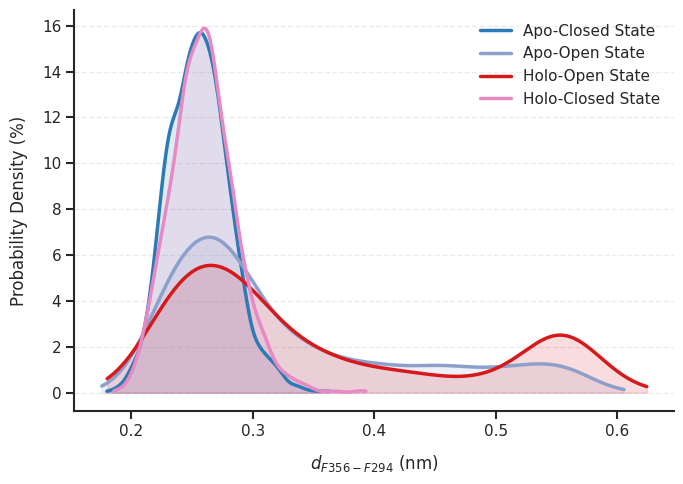

In [18]:
# 1. 设置全局样式，让图表更有“论文感”
sns.set_theme(style="ticks") # 清爽的刻度样式
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5
})

def get_kde_data(file_path, column_name):
    data = plumed.read_as_pandas(file_path)
    values = data[column_name].values
    kde = gaussian_kde(values)
    x_range = np.linspace(np.min(values), np.max(values), 300) # 增加点数让曲线更平滑
    return x_range, kde(x_range)

# 2. 准备数据
datasets = [
    {'path': 'AgOR10_apo/cuts1/COLVAR_S6-S7', 'label': 'Apo-Closed State', 'color': '#2C7BB6'}, # 深蓝色
    {'path': 'AgOR10_apo_open/COLVAR_S6-S7', 'label': 'Apo-Open State', 'color': '#8DA0CB'}, # 深蓝色
    {'path': 'AgOR10_bound/COLVAR_S6-S7', 'label': 'Holo-Open State', 'color': '#D7191C'}, # 暖红色
    {'path': 'AgOR10_bound_close/COLVAR_S6-S7', 'label': 'Holo-Closed State', 'color': '#E78AC3'} # 暖红色
]


fig, ax = plt.subplots(figsize=(7, 5))

# 3. 循环绘图
for ds in datasets:
    x, y = get_kde_data(ds['path'], 'd_A_PHE356_A_PHE294.min')
    
    # 画主线
    ax.plot(x, y, color=ds['color'], label=ds['label'], lw=2.5, zorder=2)
    # 填充颜色，使用较淡的 alpha 值
    ax.fill_between(x, y, color=ds['color'], alpha=0.15, zorder=1)

# 4. 精修图表细节
ax.set_xlabel(r'$d_{F356-F294}$ (nm)', labelpad=10)
ax.set_ylabel('Probability Density (%)', labelpad=10)
# ax.set_title('Lipid Distribution Comparison', fontsize=14, pad=15)

# 去掉上方和右方的边框
sns.despine()

# 添加网格（可选，淡淡的灰色网格有助于读数）
ax.grid(axis='y', linestyle='--', alpha=0.4)

# 优化图例
ax.legend(frameon=False)
# 自动调整布局，防止边缘裁剪
plt.tight_layout()
plt.savefig('dF356-F294.pdf', dpi=300, transparent=True)
plt.show()
    


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


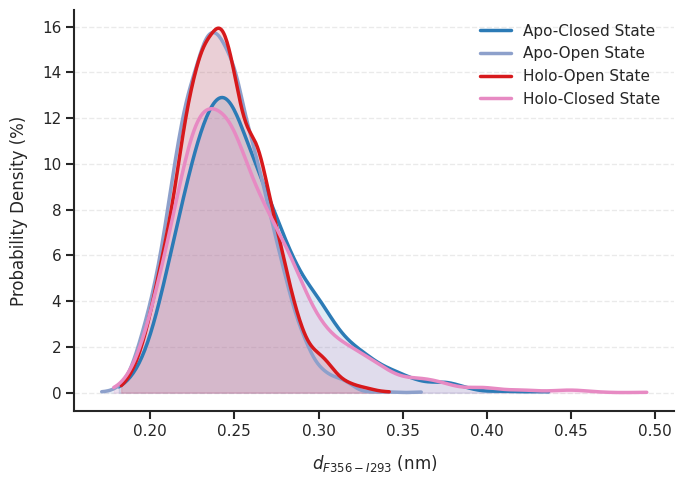

In [19]:
# 1. 设置全局样式，让图表更有“论文感”
sns.set_theme(style="ticks") # 清爽的刻度样式
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5
})

def get_kde_data(file_path, column_name):
    data = plumed.read_as_pandas(file_path)
    values = data[column_name].values
    kde = gaussian_kde(values)
    x_range = np.linspace(np.min(values), np.max(values), 300) # 增加点数让曲线更平滑
    return x_range, kde(x_range)

# 2. 准备数据
datasets = [
    {'path': 'AgOR10_apo/cuts1/COLVAR_S6-S7', 'label': 'Apo-Closed State', 'color': '#2C7BB6'}, # 深蓝色
    {'path': 'AgOR10_apo_open/COLVAR_S6-S7', 'label': 'Apo-Open State', 'color': '#8DA0CB'}, # 深蓝色
    {'path': 'AgOR10_bound/COLVAR_S6-S7', 'label': 'Holo-Open State', 'color': '#D7191C'}, # 暖红色
    {'path': 'AgOR10_bound_close/COLVAR_S6-S7', 'label': 'Holo-Closed State', 'color': '#E78AC3'} # 暖红色
]

fig, ax = plt.subplots(figsize=(7, 5))

# 3. 循环绘图
for ds in datasets:
    x, y = get_kde_data(ds['path'], 'd_A_PHE356_A_ILE293.min')
    
    # 画主线
    ax.plot(x, y, color=ds['color'], label=ds['label'], lw=2.5, zorder=2)
    # 填充颜色，使用较淡的 alpha 值
    ax.fill_between(x, y, color=ds['color'], alpha=0.15, zorder=1)

# 4. 精修图表细节
ax.set_xlabel(r'$d_{F356-I293}$ (nm)', labelpad=10)
ax.set_ylabel('Probability Density (%)', labelpad=10)
# ax.set_title('Lipid Distribution Comparison', fontsize=14, pad=15)

# 去掉上方和右方的边框
sns.despine()

# 添加网格（可选，淡淡的灰色网格有助于读数）
ax.grid(axis='y', linestyle='--', alpha=0.4)

# 优化图例
ax.legend(frameon=False)

# 自动调整布局，防止边缘裁剪
plt.tight_layout()
plt.savefig('dF356-F293.pdf', dpi=300, transparent=True)
plt.show()
    


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


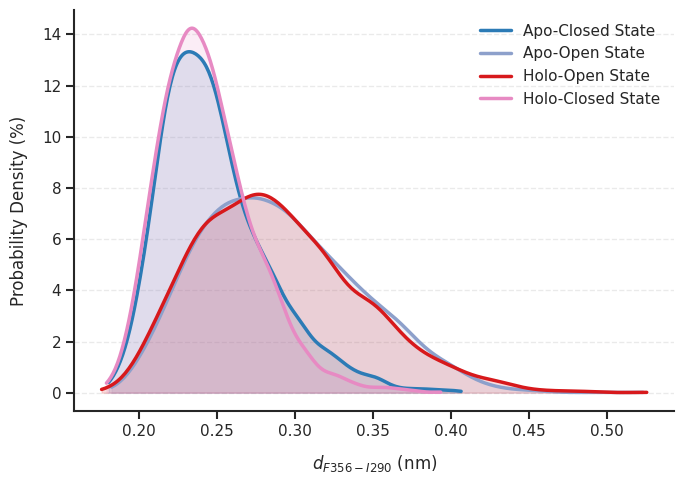

In [ ]:
# 1. 设置全局样式，让图表更有“论文感”
sns.set_theme(style="ticks") # 清爽的刻度样式
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5
})

def get_kde_data(file_path, column_name):
    data = plumed.read_as_pandas(file_path)
    values = data[column_name].values
    kde = gaussian_kde(values)
    x_range = np.linspace(np.min(values), np.max(values), 300) # 增加点数让曲线更平滑
    return x_range, kde(x_range)

# 2. 准备数据
datasets = [
    {'path': 'AgOR10_apo/cuts1/COLVAR_S6-S7', 'label': 'Apo-Closed State', 'color': '#2C7BB6'}, # 深蓝色
    {'path': 'AgOR10_apo_open/COLVAR_S6-S7', 'label': 'Apo-Open State', 'color': '#8DA0CB'}, # 深蓝色
    {'path': 'AgOR10_bound/COLVAR_S6-S7', 'label': 'Holo-Open State', 'color': '#D7191C'}, # 暖红色
    {'path': 'AgOR10_bound_close/COLVAR_S6-S7', 'label': 'Holo-Closed State', 'color': '#E78AC3'} # 暖红色
]

fig, ax = plt.subplots(figsize=(7, 5))

# 3. 循环绘图
for ds in datasets:
    x, y = get_kde_data(ds['path'], 'd_A_PHE356_A_ILE290.min')
    
    # 画主线
    ax.plot(x, y, color=ds['color'], label=ds['label'], lw=2.5, zorder=2)
    # 填充颜色，使用较淡的 alpha 值
    ax.fill_between(x, y, color=ds['color'], alpha=0.15, zorder=1)

# 4. 精修图表细节
ax.set_xlabel(r'$d_{F356-I290}$ (nm)', labelpad=10)
ax.set_ylabel('Probability Density (%)', labelpad=10)
# ax.set_title('Lipid Distribution Comparison', fontsize=14, pad=15)

# 去掉上方和右方的边框
sns.despine()

# 添加网格（可选，淡淡的灰色网格有助于读数）
ax.grid(axis='y', linestyle='--', alpha=0.4)

# 优化图例
ax.legend(frameon=False)

# 自动调整布局，防止边缘裁剪
plt.tight_layout()
plt.savefig('dF356-I290.pdf', dpi=300, transparent=True)
plt.show()
    


In [56]:
np.sum(y)*360/200

np.float64(99.49999999999669)

In [ ]:
def get_kde_data(file_path, cv_name):
    data = plumed.read_as_pandas(file_path)
    kb = 0.0083145
    T = 310
    kbT = kb * T  
    
    # 1. 提取原始数据
    x_raw = data[cv_name].values
    f_raw = data['file.free'].values
    
    # 2. 角度转换并【重新排序】
    # 使用 % 360 将范围转为 [0, 360)
    x_converted = x_raw % 360
    
    # 关键步骤：按角度从小到大排序，否则绘图和插值会乱
    sort_idx = np.argsort(x_converted)
    x_sorted = x_converted[sort_idx]
    f_sorted = f_raw[sort_idx]

    # 3. 转换为概率密度 (Boltzmann)
    # 减去最小值是为了数值稳定性（防止 exp 爆炸）
    p_raw = np.exp(-(f_sorted - np.min(f_sorted)) / kbT)
    
    # 4. 构建统一网格进行插值
    # 建议固定为 0-360，这样不同数据集的 x 轴才完全对齐
    x_unified = np.linspace(0, 360, 500) 
    
    # 使用 periodic 包装或简单的线性插值
    # 如果数据点覆盖了整个范围，linear 即可；
    # 如果边缘有缺失，建议 fill_value 用 0 或边界值
    interp_func = interp1d(x_sorted, p_raw, kind='linear', 
                           bounds_error=False, fill_value=(p_raw[0], p_raw[-1]))
    
    prob_new = interp_func(x_unified)

    # 5. 归一化：使曲线下方曲线面积为 1 (PDF) 或总和为 1
    # 论文中通常使用积分归一化，即 np.trapz
    dx = x_unified[1] - x_unified[0]
    prob_new /= (np.trapz(prob_new, x_unified) + 1e-12)
    
    # 如果你想显示百分比，可以乘以 100，或者在绘图轴上处理
    return x_unified, prob_new * 100

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


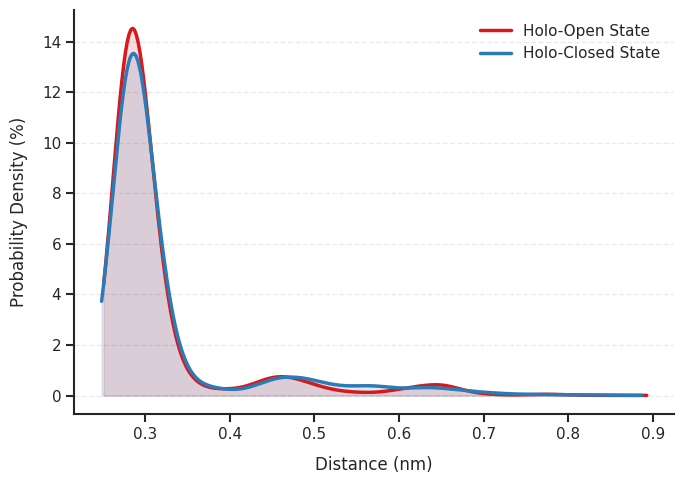

In [50]:
# 1. 设置全局样式，让图表更有“论文感”
sns.set_theme(style="ticks") # 清爽的刻度样式
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5
})

def get_kde_data(file_path, column_name):
    data = plumed.read_as_pandas(file_path)
    values = data[column_name].values
    kde = gaussian_kde(values)
    x_range = np.linspace(np.min(values), np.max(values), 300) # 增加点数让曲线更平滑
    return x_range, kde(x_range)

# 2. 准备数据
datasets = [
    {'path': 'AgOR10_bound/COLVAR_d-S133', 'label': 'Holo-Open State', 'color': '#D7191C'}, # 暖红色
    {'path': 'AgOR10_bound_close/COLVAR_d-S133', 'label': 'Holo-Closed State', 'color': '#2C7BB6'} # 深蓝色
]

fig, ax = plt.subplots(figsize=(7, 5))

# 3. 循环绘图
for ds in datasets:
    x, y = get_kde_data(ds['path'], 'dl-S133')
    
    # 画主线
    ax.plot(x, y, color=ds['color'], label=ds['label'], lw=2.5, zorder=2)
    # 填充颜色，使用较淡的 alpha 值
    ax.fill_between(x, y, color=ds['color'], alpha=0.15, zorder=1)

# 4. 精修图表细节
ax.set_xlabel('Distance (nm)', labelpad=10)
ax.set_ylabel('Probability Density (%)', labelpad=10)
# ax.set_title('Lipid Distribution Comparison', fontsize=14, pad=15)

# 去掉上方和右方的边框
sns.despine()

# 添加网格（可选，淡淡的灰色网格有助于读数）
ax.grid(axis='y', linestyle='--', alpha=0.4)

# 优化图例
ax.legend(frameon=False, loc='upper right', fontsize=11)

# 自动调整布局，防止边缘裁剪
plt.tight_layout()
plt.savefig('dl-S133_comparison.pdf', dpi=300, transparent=True)
plt.show()
    


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' no

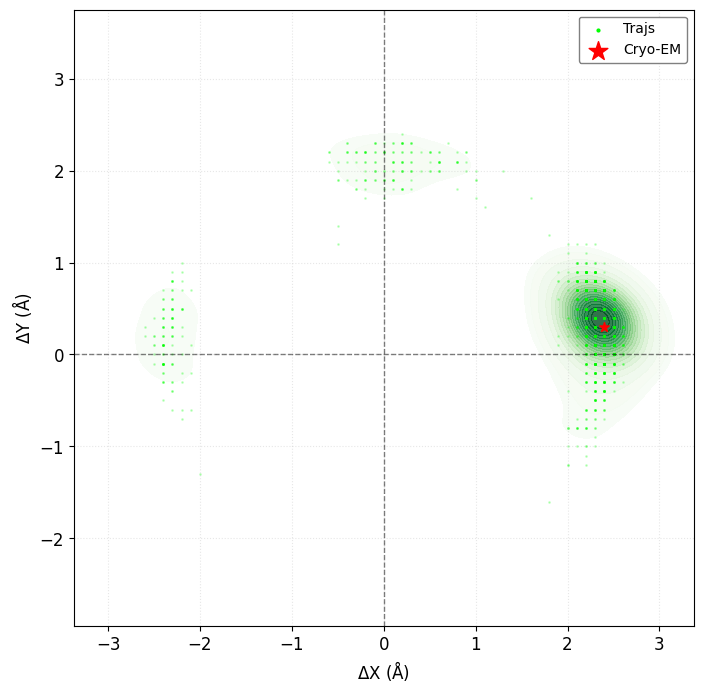

In [2]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 12

# 数学公式字体
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Arial'
mpl.rcParams['mathtext.it'] = 'Arial:italic'
mpl.rcParams['mathtext.bf'] = 'Arial:bold'
# ================= 配置区域 =================
pdb_file = 'AgOR10_bound/ligand.pdb' 
selection1 = 'index 3' 
selection2 = 'index 1' 
# ===========================================

u = mda.Universe(pdb_file)
atom_start = u.select_atoms(selection1)
atom_end = u.select_atoms(selection2)

vectors_xy = []
for ts in u.trajectory:
    # 计算相对矢量：原子2相对于原子1的位置
    vec_3d = atom_end.positions[0] - atom_start.positions[0]
    vectors_xy.append(vec_3d[:2]) 

vectors_xy = np.array(vectors_xy)
U = vectors_xy[:, 0]  # 相对 X 位移
V = vectors_xy[:, 1]  # 相对 Y 位移

# 4. 绘图
plt.figure(figsize=(8, 8))

# --- 绘制二维密度图 (KDE) ---
# fill=True 填充颜色，cmap 设置色板（可以使用 'Blues', 'viridis', 'rocket'）
sns.kdeplot(x=U, y=V, fill=True, thresh=0.05, levels=20, cmap="Greens", alpha=0.8)

# --- 绘制散点 (可选，用于观察具体样本点) ---
plt.scatter(U, V, s=1, color='#00FF00', alpha=0.2, label='Trajs')

# --- 突出显示第一帧 ---
plt.scatter(U[0], V[0], color='red', s=50, marker='*', 
            zorder=10, label='Cryo-EM')

# 5. 图形美化
# 绘制原点参考线 (此时原点代表原子1的位置)
plt.axhline(0, color='black', linewidth=1, alpha=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=1, alpha=0.5, linestyle='--')
# plt.scatter(0, 0, color='black', marker='+', s=100, label='Origin (Atom 1)')

# 坐标轴自动根据分布范围调整
# limit = np.max(np.abs(vectors_xy)) * 1.3
# plt.xlim(-limit, limit)
# plt.ylim(-limit, limit)

plt.xlabel('$\Delta$X (Å)', fontsize=12)
plt.ylabel('$\Delta$Y (Å)', fontsize=12)
# plt.title('2D Density Distribution of Atom 2 Relative to Atom 1\n(XY Projection)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.3)
leg = plt.legend(
    loc='upper right', 
    fontsize=10,            # 文字大小
    frameon=True,           # 是否显示背景边框
    framealpha=1,         # 边框透明度 (0.5 为半透明)
    edgecolor='gray',       # 边框颜色
    markerscale=2.0,        # 让图例里的星星和点放大 2 倍，看得更清楚
)
for lh in leg.legend_handles: 
    lh.set_alpha(1.0)
plt.axis('equal') 
plt.savefig('vector_density_plot.svg', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

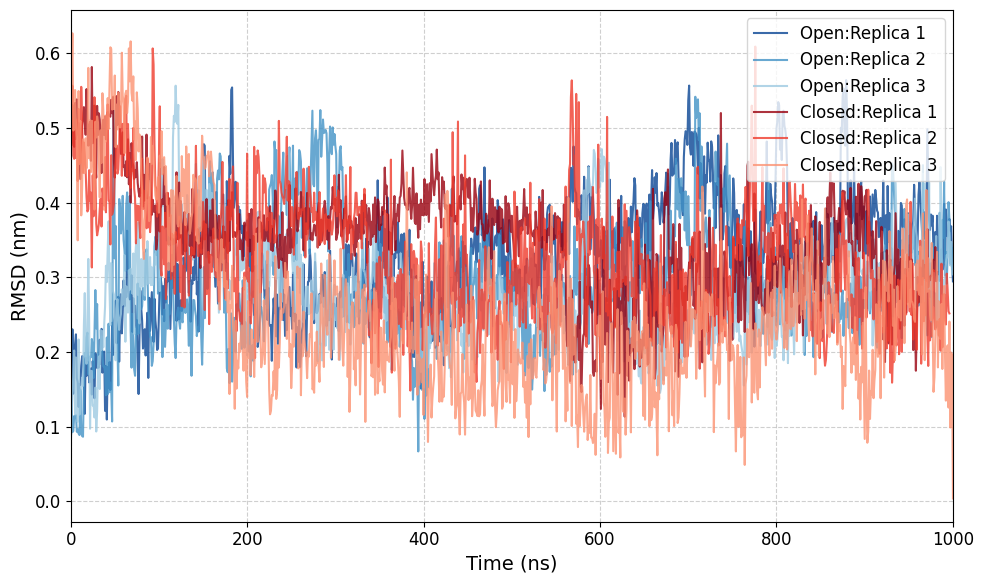

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义文件列表和对应的标签
files = ['AgOR10_bound/rmsd1.xvg', 'AgOR10_bound/rmsd2.xvg', 'AgOR10_bound/rmsd3.xvg','AgOR10_bound_close/rmsd1.xvg', 'AgOR10_bound_close/rmsd2.xvg', 'AgOR10_bound_close/rmsd3.xvg']
labels = ['Open:Replica 1', 'Open:Replica 2', 'Open:Replica 3', 'Closed:Replica 1', 'Closed:Replica 2', 'Closed:Replica 3']
colors = [
    '#084594', '#4292c6', '#9ecae1',  # 蓝色系 (Open)
    '#99000d', '#ef3b2c', '#fc9272'   # 红色系 (Closed)
]

plt.figure(figsize=(10, 6))

# 2. 循环读取并绘图
for file, label, color in zip(files, labels, colors):
    # np.loadtxt 会自动忽略以 # 和 @ 开头的行
    data = np.loadtxt(file, comments=['#', '@'])
    
    time = data[:, 0]/1000  # 第一列：时间 (ps)
    rmsd = data[:, 1]  # 第二列：RMSD (nm)
    
    plt.plot(time, rmsd, label=label, color=color, linewidth=1.5, alpha=0.8)

# 3. 图形美化（参考 GROMACS 默认单位）
# plt.title("RMSD Analysis", fontsize=16)
plt.xlabel("Time (ns)", fontsize=14)
plt.ylabel("RMSD (nm)", fontsize=14)
plt.xlim(0,1000)
# 设置网格和图例
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=12)

# 优化边距
plt.tight_layout()

# 4. 显示或保存
plt.savefig('combined_rmsd.pdf', dpi=300)
plt.show()